# CheXpert — Dataset Exploration & Analysis

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

DATA_ROOT = Path(r"D:\CheXpert-v1.0-small")

train_df = pd.read_csv(DATA_ROOT / "train.csv")
valid_df = pd.read_csv(DATA_ROOT / "valid.csv")

print("train.csv:", train_df.shape)
print("valid.csv:", valid_df.shape)
train_df.head()

train.csv: (223414, 19)
valid.csv: (234, 19)


,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [2]:
# Per-pathology breakdown of label values in train.csv
LABEL_COLS = [
    "No Finding", "Enlarged Cardiomediastinum", "Cardiomegaly", "Lung Opacity",
    "Lung Lesion", "Edema", "Consolidation", "Pneumonia", "Atelectasis",
    "Pneumothorax", "Pleural Effusion", "Pleural Other", "Fracture", "Support Devices",
]

n = len(train_df)
rows = []
for col in LABEL_COLS:
    s = train_df[col]
    pos   = (s == 1).sum()
    neg   = (s == 0).sum()
    unc   = (s == -1).sum()
    blank = s.isna().sum()
    mentioned = pos + neg + unc          # rows where the pathology was actually mentioned
    rows.append({
        "pathology": col,
        "pos(1)": pos,
        "neg(0)": neg,
        "uncertain(-1)": unc,
        "blank(NaN)": blank,
        # share of ALL rows
        "%blank(all)": round(100 * blank / n, 1),
        # shares among MENTIONED rows only (the meaningful denominator)
        "%unc(ment)": round(100 * unc / mentioned, 1) if mentioned else 0.0,
        "%pos(ment)": round(100 * pos / mentioned, 1) if mentioned else 0.0,
        "%neg(ment)": round(100 * neg / mentioned, 1) if mentioned else 0.0,
    })

label_counts = pd.DataFrame(rows).set_index("pathology")
print(f"total train rows: {n}")
print("'(ment)' columns are computed over mentioned rows only = pos + neg + unc (blanks excluded)")
label_counts

total train rows: 223414
'(ment)' columns are computed over mentioned rows only = pos + neg + unc (blanks excluded)


,pos(1),neg(0),uncertain(-1),blank(NaN),%blank(all),%unc(ment),%pos(ment),%neg(ment)
pathology,,,,,,,,
No Finding,22381,0,0,201033,90.0,0.0,100.0,0.0
Enlarged Cardiomediastinum,10798,21638,12403,178575,79.9,27.7,24.1,48.3
Cardiomegaly,27000,11116,8087,177211,79.3,17.5,58.4,24.1
Lung Opacity,105581,6599,5598,105636,47.3,4.8,89.6,5.6
Lung Lesion,9186,1270,1488,211470,94.7,12.5,76.9,10.6
Edema,52246,20726,12984,137458,61.5,15.1,60.8,24.1
Consolidation,14783,28097,27742,152792,68.4,39.3,20.9,39.8
Pneumonia,6039,2799,18770,195806,87.6,68.0,21.9,10.1
Atelectasis,33376,1328,33739,154971,69.4,49.3,48.8,1.9


In [3]:
# Same breakdown, restricted to the 5 target competition tasks
TARGET_TASKS = ["Atelectasis", "Cardiomegaly", "Consolidation", "Edema", "Pleural Effusion"]

target_counts = label_counts.loc[TARGET_TASKS]
target_counts

,pos(1),neg(0),uncertain(-1),blank(NaN),%blank(all),%unc(ment),%pos(ment),%neg(ment)
pathology,,,,,,,,
Atelectasis,33376,1328,33739,154971,69.4,49.3,48.8,1.9
Cardiomegaly,27000,11116,8087,177211,79.3,17.5,58.4,24.1
Consolidation,14783,28097,27742,152792,68.4,39.3,20.9,39.8
Edema,52246,20726,12984,137458,61.5,15.1,60.8,24.1
Pleural Effusion,86187,35396,11628,90203,40.4,8.7,64.7,26.6


In [4]:
# Resulting class balance per target task under U-Ones vs U-Zeros
# (blanks/NaN -> 0 in both cases; percentages over ALL train rows)
rows = []
for col in TARGET_TASKS:
    s = train_df[col]
    pos = (s == 1).sum()
    unc = (s == -1).sum()
    uones_pos  = pos + unc       # uncertain -> positive
    uzeros_pos = pos             # uncertain -> negative
    rows.append({
        "task": col,
        "U-Ones %pos":  round(100 * uones_pos  / n, 1),
        "U-Ones %neg":  round(100 * (n - uones_pos)  / n, 1),
        "U-Zeros %pos": round(100 * uzeros_pos / n, 1),
        "U-Zeros %neg": round(100 * (n - uzeros_pos) / n, 1),
    })

policy_prevalence = pd.DataFrame(rows).set_index("task")
print(f"total train rows: {n}  (percentages over the whole dataset)")
policy_prevalence

total train rows: 223414  (percentages over the whole dataset)


,U-Ones %pos,U-Ones %neg,U-Zeros %pos,U-Zeros %neg
task,,,,
Atelectasis,30.0,70.0,14.9,85.1
Cardiomegaly,15.7,84.3,12.1,87.9
Consolidation,19.0,81.0,6.6,93.4
Edema,29.2,70.8,23.4,76.6
Pleural Effusion,43.8,56.2,38.6,61.4


In [5]:
# Check whether uncertain(-1)/blank labels exist in valid (and test) for the 5 tasks
def label_value_breakdown(df, name):
    rows = []
    for col in TARGET_TASKS:
        s = df[col]
        rows.append({
            "task": col,
            "pos(1)": (s == 1).sum(),
            "neg(0)": (s == 0).sum(),
            "uncertain(-1)": (s == -1).sum(),
            "blank(NaN)": s.isna().sum(),
        })
    print(f"--- {name}: {len(df)} rows ---")
    return pd.DataFrame(rows).set_index("task")

display(label_value_breakdown(valid_df, "valid"))

# Test set may not be on disk yet; load only if present
test_path = DATA_ROOT / "test.csv"
if test_path.exists():
    test_df = pd.read_csv(test_path)
    display(label_value_breakdown(test_df, "test"))
else:
    print(f"test.csv not found at {test_path} (test set not added yet) - skipping")

--- valid: 234 rows ---


,pos(1),neg(0),uncertain(-1),blank(NaN)
task,,,,
Atelectasis,80,154,0,0
Cardiomegaly,68,166,0,0
Consolidation,33,201,0,0
Edema,45,189,0,0
Pleural Effusion,67,167,0,0


--- test: 668 rows ---


,pos(1),neg(0),uncertain(-1),blank(NaN)
task,,,,
Atelectasis,178,490,0,0
Cardiomegaly,175,493,0,0
Consolidation,35,633,0,0
Edema,85,583,0,0
Pleural Effusion,120,548,0,0


In [6]:
# View distribution: Frontal vs Lateral, and AP vs PA within frontals
# (test.csv lacks the Frontal/Lateral & AP/PA columns -> derive view from the filename)
splits = [("train", train_df), ("valid", valid_df)]
if "test_df" in dir():
    splits.append(("test", test_df))

def get_view(df):
    if "Frontal/Lateral" in df.columns:
        return df["Frontal/Lateral"]
    return np.where(df["Path"].str.contains("frontal"), "Frontal",
           np.where(df["Path"].str.contains("lateral"), "Lateral", "Unknown"))

for name, df in splits:
    print(f"--- {name}: {len(df)} images ---")
    view = pd.Series(get_view(df), index=df.index)
    print("Frontal/Lateral:")
    for k, v in view.value_counts(dropna=False).items():
        print(f"   {k!s:10s} {v:>7d}  ({100*v/len(df):.1f}%)")
    if "AP/PA" in df.columns:
        frontal = df[view == "Frontal"]
        print(f"AP/PA (within {len(frontal)} frontals):")
        for k, v in frontal["AP/PA"].value_counts(dropna=False).items():
            print(f"   {k!s:10s} {v:>7d}  ({100*v/len(frontal):.1f}%)")
    else:
        print("AP/PA: column not in this split")
    print()

--- train: 223414 images ---
Frontal/Lateral:
   Frontal     191027  (85.5%)
   Lateral      32387  (14.5%)
AP/PA (within 191027 frontals):
   AP          161590  (84.6%)
   PA           29420  (15.4%)
   LL              16  (0.0%)
   RL               1  (0.0%)

--- valid: 234 images ---
Frontal/Lateral:
   Frontal        202  (86.3%)
   Lateral         32  (13.7%)
AP/PA (within 202 frontals):
   AP             169  (83.7%)
   PA              33  (16.3%)

--- test: 668 images ---
Frontal/Lateral:
   Frontal        518  (77.5%)
   Lateral        150  (22.5%)
AP/PA: column not in this split



In [7]:
# Patient / study structure (frontal-only), parsed from Path
# Path: .../{split}/patientXXXXX/studyY/viewZ_frontal.jpg
for name, df in splits:
    view = pd.Series(get_view(df), index=df.index)
    f = df[view == "Frontal"]
    pid   = f["Path"].str.extract(r"(patient\d+)", expand=False)
    study = f["Path"].str.extract(r"(patient\d+/study\d+)", expand=False)

    studies_per_patient = study.groupby(pid).nunique()
    frontals_per_study  = study.value_counts()
    multi = (frontals_per_study > 1).sum()

    print(f"--- {name} (frontal-only): {len(f)} images ---")
    print(f"   patients : {pid.nunique()}")
    print(f"   studies  : {study.nunique()}")
    print(f"   studies/patient : mean {studies_per_patient.mean():.2f}, max {studies_per_patient.max()}")
    print(f"   frontals/study  : mean {frontals_per_study.mean():.2f}, max {frontals_per_study.max()}")
    print(f"   studies with >1 frontal: {multi} ({100*multi/study.nunique():.1f}%)")
    print()

--- train (frontal-only): 191027 images ---
   patients : 64534
   studies  : 187625
   studies/patient : mean 2.91, max 91
   frontals/study  : mean 1.02, max 3
   studies with >1 frontal: 3361 (1.8%)

--- valid (frontal-only): 202 images ---
   patients : 200
   studies  : 200
   studies/patient : mean 1.00, max 1
   frontals/study  : mean 1.01, max 2
   studies with >1 frontal: 2 (1.0%)

--- test (frontal-only): 518 images ---
   patients : 500
   studies  : 500
   studies/patient : mean 1.00, max 1
   frontals/study  : mean 1.04, max 2
   studies with >1 frontal: 18 (3.6%)



In [8]:
# Verify the three official splits share NO patients (no cross-split leakage)
def patient_ids(df):
    return set(df["Path"].str.extract(r"(patient\d+)", expand=False))

p_train, p_valid, p_test = patient_ids(train_df), patient_ids(valid_df), patient_ids(test_df)

print(f"patients  train={len(p_train)}  valid={len(p_valid)}  test={len(p_test)}")
print(f"train  ∩ valid : {len(p_train & p_valid)} shared")
print(f"train  ∩ test  : {len(p_train & p_test)} shared")
print(f"valid  ∩ test  : {len(p_valid & p_test)} shared")

patients  train=64540  valid=200  test=500
train  ∩ valid : 0 shared
train  ∩ test  : 0 shared
valid  ∩ test  : 0 shared


--- train: 223414 images ---
Sex:
   Male        132636  (59.4%)
   Female       90777  (40.6%)
   Unknown          1  (0.0%)
Age:  min 0  max 90  mean 60.4  median 62
   age == 0 : 3   age > 100 : 0   missing : 0

--- valid: 234 images ---
Sex:
   Male           128  (54.7%)
   Female         106  (45.3%)
Age:  min 18  max 90  mean 60.8  median 62
   age == 0 : 0   age > 100 : 0   missing : 0



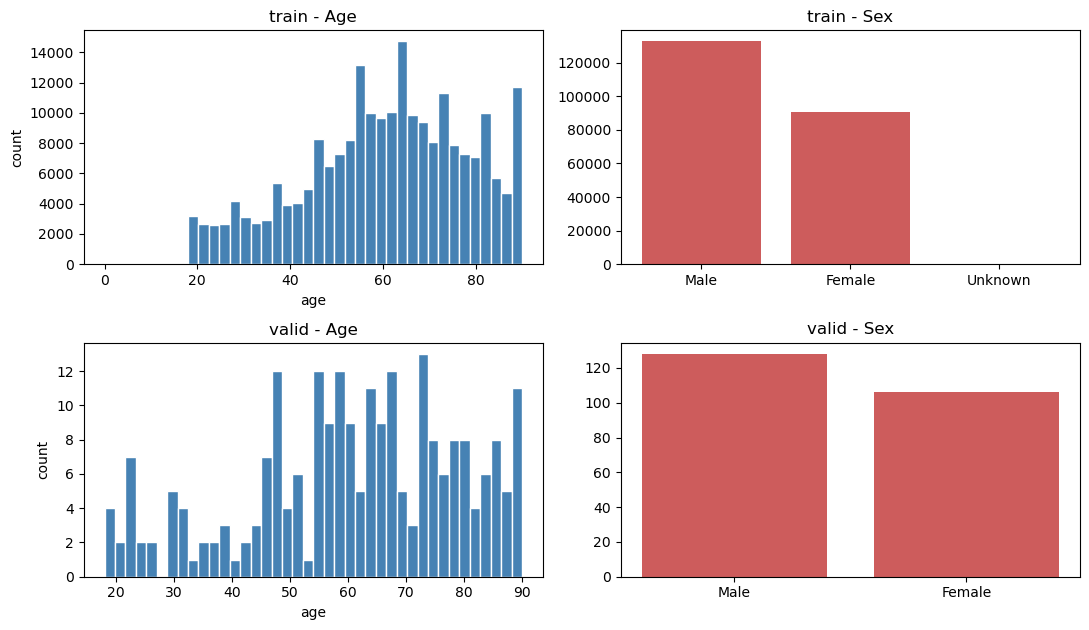

In [9]:
# Demographics: Sex and Age  (train & valid have these columns; test does not)
import matplotlib.pyplot as plt

demo_splits = [(nm, df) for nm, df in splits if "Age" in df.columns and "Sex" in df.columns]

for name, df in demo_splits:
    print(f"--- {name}: {len(df)} images ---")
    print("Sex:")
    for k, v in df["Sex"].value_counts(dropna=False).items():
        print(f"   {k!s:10s} {v:>7d}  ({100*v/len(df):.1f}%)")
    age = df["Age"]
    print("Age:  min {:.0f}  max {:.0f}  mean {:.1f}  median {:.0f}".format(
        age.min(), age.max(), age.mean(), age.median()))
    print(f"   age == 0 : {(age == 0).sum()}   age > 100 : {(age > 100).sum()}   missing : {age.isna().sum()}")
    print()

# Age histogram + Sex bar per split
fig, axes = plt.subplots(len(demo_splits), 2, figsize=(11, 3.2 * len(demo_splits)))
if len(demo_splits) == 1:
    axes = axes.reshape(1, 2)
for i, (name, df) in enumerate(demo_splits):
    axes[i, 0].hist(df["Age"].dropna(), bins=40, color="steelblue", edgecolor="white")
    axes[i, 0].set_title(f"{name} - Age"); axes[i, 0].set_xlabel("age"); axes[i, 0].set_ylabel("count")
    sc = df["Sex"].value_counts()
    axes[i, 1].bar(sc.index.astype(str), sc.values, color="indianred")
    axes[i, 1].set_title(f"{name} - Sex")
plt.tight_layout()
plt.show()

In [12]:
# Image-level inspection: dimensions, channels, intensity range (sampled frontal JPGs)
from PIL import Image

def resolve_path(rel):
    # train/valid paths start with "CheXpert-v1.0-small/..."; test paths start with "test/..."
    for base in (DATA_ROOT.parent, DATA_ROOT):
        p = base / rel
        if p.exists():
            return p
    return None

SAMPLE_N       = 300    # images sampled per split (valid/test)
SAMPLE_N_TRAIN = 8000    # images sampled from the train split specifically

for name, df in splits:
    n_sample = SAMPLE_N_TRAIN if name == "train" else SAMPLE_N
    view = pd.Series(get_view(df), index=df.index)
    f = df[view == "Frontal"]
    idx = np.random.choice(f.index, size=min(n_sample, len(f)), replace=False)

    sizes, modes, gmin, gmax = [], [], [], []
    missing = 0
    for rel in f.loc[idx, "Path"]:
        p = resolve_path(rel)
        if p is None:
            missing += 1
            continue
        with Image.open(p) as im:
            sizes.append(im.size)          # (width, height)
            modes.append(im.mode)          # 'L' = grayscale, 'RGB' = 3-ch
            arr = np.asarray(im)
            gmin.append(arr.min()); gmax.append(arr.max())

    ws = [s[0] for s in sizes]; hs = [s[1] for s in sizes]
    print(f"--- {name}: sampled {len(sizes)} frontal images (missing files: {missing}) ---")
    print(f"   width  : min {min(ws)}  max {max(ws)}  median {int(np.median(ws))}")
    print(f"   height : min {min(hs)}  max {max(hs)}  median {int(np.median(hs))}")
    print(f"   unique (w,h) pairs in sample: {len(set(sizes))}")
    print(f"   channel modes: {pd.Series(modes).value_counts().to_dict()}")
    print(f"   intensity: global min {min(gmin)}  global max {max(gmax)}")
    print()

--- train: sampled 8000 frontal images (missing files: 0) ---
   width  : min 320  max 483  median 390
   height : min 320  max 390  median 320
   unique (w,h) pairs in sample: 117
   channel modes: {'L': 8000}
   intensity: global min 0  global max 255

--- valid: sampled 202 frontal images (missing files: 0) ---
   width  : min 320  max 397  median 390
   height : min 320  max 372  median 320
   unique (w,h) pairs in sample: 23
   channel modes: {'L': 202}
   intensity: global min 0  global max 255

--- test: sampled 300 frontal images (missing files: 0) ---
   width  : min 1763  max 4240  median 2828
   height : min 1531  max 3480  median 2320
   unique (w,h) pairs in sample: 57
   channel modes: {'L': 300}
   intensity: global min 0  global max 255



measured 191027 train frontals
aspect ratio (w/h): min 0.742  max 2.906  mean 1.192  median 1.219
   square (~1.0): 8.2%   landscape (>1): 91.3%   portrait (<1): 1.8%


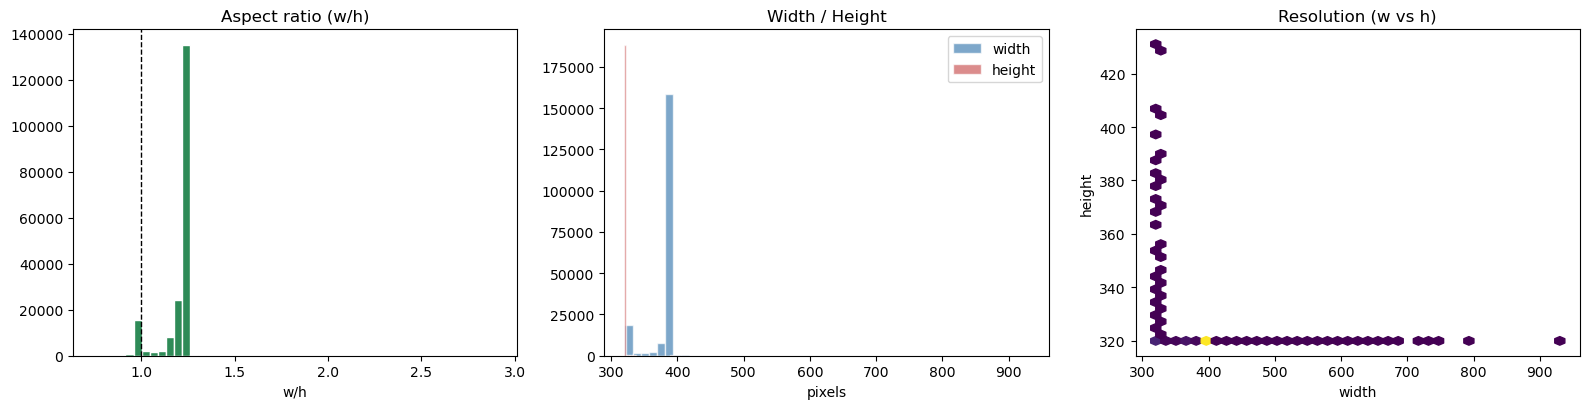

In [15]:
# Aspect-ratio & resolution distribution (TRAIN frontals only)
N_DIMS = len(train_frontal)   # how many train frontals to measure

train_view = pd.Series(get_view(train_df), index=train_df.index)
train_frontal = train_df[train_view == "Frontal"]
idx = np.random.choice(train_frontal.index, size=min(N_DIMS, len(train_frontal)), replace=False)

ws, hs = [], []
for rel in train_frontal.loc[idx, "Path"]:
    p = resolve_path(rel)
    if p is None:
        continue
    with Image.open(p) as im:
        w, h = im.size
        ws.append(w); hs.append(h)

ws, hs = np.array(ws), np.array(hs)
ar = ws / hs   # aspect ratio = width / height

print(f"measured {len(ws)} train frontals")
print(f"aspect ratio (w/h): min {ar.min():.3f}  max {ar.max():.3f}  mean {ar.mean():.3f}  median {np.median(ar):.3f}")
print(f"   square (~1.0): {(np.abs(ar-1)<0.02).mean()*100:.1f}%   landscape (>1): {(ar>1).mean()*100:.1f}%   portrait (<1): {(ar<1).mean()*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].hist(ar, bins=50, color="seagreen", edgecolor="white")
axes[0].axvline(1.0, color="k", ls="--", lw=1); axes[0].set_title("Aspect ratio (w/h)"); axes[0].set_xlabel("w/h")
axes[1].hist(ws, bins=50, color="steelblue", edgecolor="white", alpha=0.7, label="width")
axes[1].hist(hs, bins=50, color="indianred",  edgecolor="white", alpha=0.7, label="height")
axes[1].set_title("Width / Height"); axes[1].set_xlabel("pixels"); axes[1].legend()
axes[2].hexbin(ws, hs, gridsize=40, cmap="viridis", mincnt=1)
axes[2].set_title("Resolution (w vs h)"); axes[2].set_xlabel("width"); axes[2].set_ylabel("height")
plt.tight_layout(); plt.show()

In [17]:
# Most common exact resolutions across the train sample (reuses ws/hs from previous cell)
TOP_K = 15

res = pd.Series([f"{w}x{h}" for w, h in zip(ws, hs)])
vc = res.value_counts()
total = len(res)

top = vc.head(TOP_K)
res_table = pd.DataFrame({
    "resolution": top.index,
    "count": top.values,
    "%": (100 * top.values / total).round(2),
}).set_index("resolution")
res_table["cumulative %"] = res_table["%"].cumsum().round(2)

# Extremes: smallest/largest by area, per-dimension ranges, and rarest resolution
area = ws * hs
i_small, i_big = int(area.argmin()), int(area.argmax())
print(f"measured {total} train frontals;  {vc.size} distinct resolutions")
print(f"smallest by area : {ws[i_small]}x{hs[i_small]}  ({area[i_small]:,} px)")
print(f"largest  by area : {ws[i_big]}x{hs[i_big]}  ({area[i_big]:,} px)")
print(f"width  range : {ws.min()} -> {ws.max()}        height range : {hs.min()} -> {hs.max()}")
print(f"rarest resolution: {vc.index[-1]}  (count {vc.iloc[-1]})")
res_table

measured 191027 train frontals;  264 distinct resolutions
smallest by area : 320x320  (102,400 px)
largest  by area : 930x320  (297,600 px)
width  range : 320 -> 930        height range : 320 -> 431
rarest resolution: 474x320  (count 1)


,count,%,cumulative %
resolution,,,
390x320,134602,70.46,70.46
389x320,21871,11.45,81.91
320x320,13163,6.89,88.80
369x320,3432,1.80,90.60
371x320,1590,0.83,91.43
384x320,777,0.41,91.84
370x320,749,0.39,92.23
320x321,483,0.25,92.48
368x320,364,0.19,92.67


In [74]:
# % of train frontals with any dimension out of [300, 400] (reuses ws/hs from the resolution cell)
over_400  = (ws > 400) | (hs > 400)
under_300 = (ws < 300) | (hs < 300)
out_range = over_400 | under_300
N = len(ws)

print(f"train frontals measured: {N}")
print(f"  any dim > 400     : {int(over_400.sum()):>6d}  ({100*over_400.mean():.2f}%)")
print(f"  any dim < 300     : {int(under_300.sum()):>6d}  ({100*under_300.mean():.2f}%)")
print(f"  out of [300,400]  : {int(out_range.sum()):>6d}  ({100*out_range.mean():.2f}%)")
print(f"  within [300,400]  : {int((~out_range).sum()):>6d}  ({100*(~out_range).mean():.2f}%)")

train frontals measured: 191027
  any dim > 400     :    781  (0.41%)
  any dim < 300     :      0  (0.00%)
  out of [300,400]  :    781  (0.41%)
  within [300,400]  : 190246  (99.59%)


Positives per task (U-Ones):
Atelectasis         59583
Cardiomegaly        30092
Consolidation       37364
Edema               61493
Pleural Effusion    86477

P(column | row) %  — given row-task positive, how often column-task is also positive:


,Atelectasis,Cardiomegaly,Consolidation,Edema,Pleural Effusion
Atelectasis,100.0,15.6,41.5,31.8,53.8
Cardiomegaly,31.0,100.0,19.1,51.8,48.9
Consolidation,66.1,15.3,100.0,28.0,54.5
Edema,30.8,25.4,17.0,100.0,50.9
Pleural Effusion,37.1,17.0,23.5,36.2,100.0


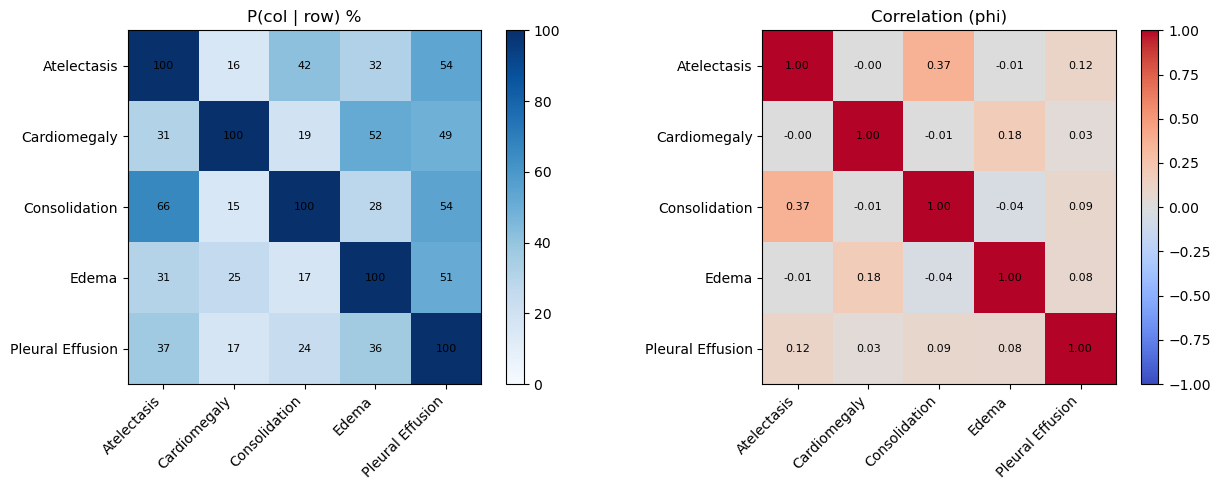

In [18]:
# Label co-occurrence among the 5 target tasks (TRAIN, frontal, U-Ones binarization)
tf = train_df[pd.Series(get_view(train_df), index=train_df.index) == "Frontal"]

# U-Ones: positive(1) and uncertain(-1) -> 1 ; negative(0) and blank(NaN) -> 0
Y = (tf[TARGET_TASKS].isin([1, -1])).astype(int)

cooc = Y.T.dot(Y)                 # raw co-occurrence counts (diagonal = positives per task)
corr = Y.corr()                   # phi correlation between tasks

# Co-occurrence as % of the row-task's positives (how often B co-occurs given A)
cooc_pct = (cooc.div(np.diag(cooc), axis=0) * 100).round(1)

print("Positives per task (U-Ones):")
print(pd.Series(np.diag(cooc), index=TARGET_TASKS).to_string())
print("\nP(column | row) %  — given row-task positive, how often column-task is also positive:")
display(cooc_pct)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im0 = axes[0].imshow(cooc_pct, cmap="Blues", vmin=0, vmax=100)
axes[0].set_title("P(col | row) %"); 
im1 = axes[1].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set_title("Correlation (phi)")
for ax in axes:
    ax.set_xticks(range(5)); ax.set_xticklabels(TARGET_TASKS, rotation=45, ha="right")
    ax.set_yticks(range(5)); ax.set_yticklabels(TARGET_TASKS)
for i in range(5):
    for j in range(5):
        axes[0].text(j, i, f"{cooc_pct.iloc[i,j]:.0f}", ha="center", va="center", fontsize=8)
        axes[1].text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im0, ax=axes[0], fraction=0.046); fig.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

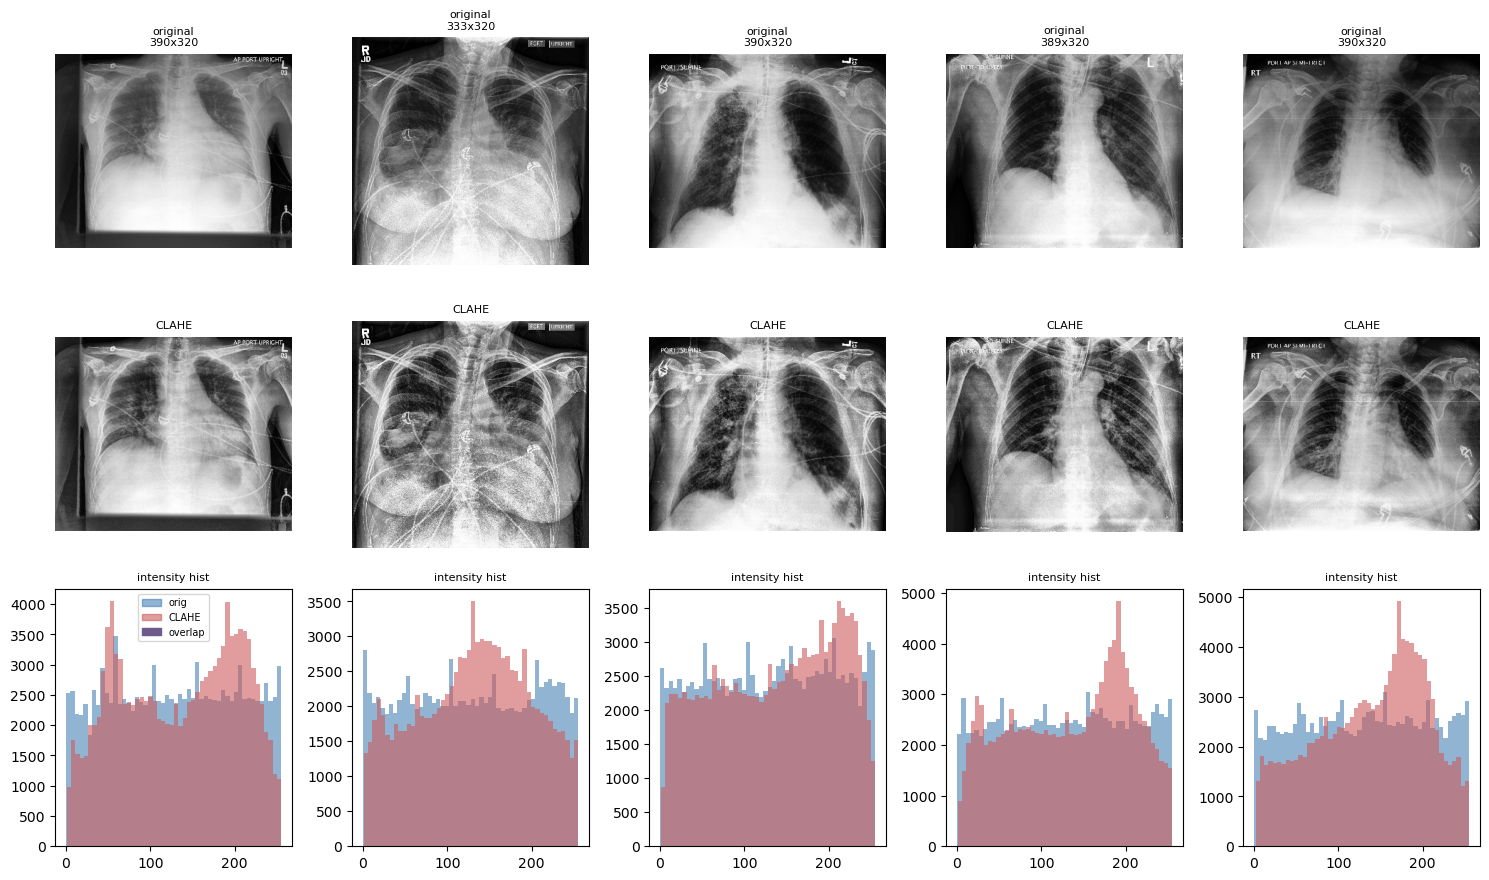

In [28]:
# Visual grid of sample frontals + CLAHE before/after preview (TRAIN)
import cv2
from matplotlib.patches import Patch

N_SHOW = 5                       # number of sample images
CLIP_LIMIT = 2.0                 # CLAHE clip limit
TILE = (8, 8)                    # CLAHE tile grid

tf_idx = np.random.choice(train_frontal.index, size=N_SHOW, replace=False)
clahe = cv2.createCLAHE(clipLimit=CLIP_LIMIT, tileGridSize=TILE)

legend_handles = [
    Patch(color="steelblue", alpha=0.6, label="orig"),
    Patch(color="indianred", alpha=0.6, label="CLAHE"),
    Patch(color="#6e5a8c", label="overlap"),   # blended color where the two overlap
]

fig, axes = plt.subplots(3, N_SHOW, figsize=(3 * N_SHOW, 9))
for j, rel in enumerate(train_frontal.loc[tf_idx, "Path"]):
    img = np.asarray(Image.open(resolve_path(rel)).convert("L"))
    out = clahe.apply(img)
    axes[0, j].imshow(img, cmap="gray"); axes[0, j].set_title(f"original\n{img.shape[1]}x{img.shape[0]}", fontsize=8)
    axes[1, j].imshow(out, cmap="gray"); axes[1, j].set_title("CLAHE", fontsize=8)
    axes[2, j].hist(img.ravel(), bins=50, alpha=0.6, color="steelblue")
    axes[2, j].hist(out.ravel(), bins=50, alpha=0.6, color="indianred")
    axes[2, j].set_title("intensity hist", fontsize=8)
    if j == 0:
        axes[2, j].legend(handles=legend_handles, fontsize=7)
for ax in axes[:2].ravel():
    ax.axis("off")
plt.tight_layout(); plt.show()

In [29]:
# Data-integrity check: does "No Finding == 1" really mean no pathology positives? (TRAIN)
PATHOLOGY_COLS = [c for c in LABEL_COLS if c != "No Finding"]   # 13 findings

nf = train_df[train_df["No Finding"] == 1]
# count rows where any pathology is positively asserted (1) despite No Finding == 1
pos_any   = (nf[PATHOLOGY_COLS] == 1).any(axis=1).sum()
unc_any   = (nf[PATHOLOGY_COLS] == -1).any(axis=1).sum()

print(f"rows with No Finding == 1 : {len(nf)}")
print(f"   of these, also have a positive(1) pathology : {pos_any}  ({100*pos_any/len(nf):.2f}%)")
print(f"   of these, also have an uncertain(-1) pathology: {unc_any}  ({100*unc_any/len(nf):.2f}%)")

if pos_any:
    print("\nContradictory positive pathologies among No Finding==1 rows:")
    print((nf[PATHOLOGY_COLS] == 1).sum().loc[lambda s: s > 0].to_string())

rows with No Finding == 1 : 22381
   of these, also have a positive(1) pathology : 8808  (39.35%)
   of these, also have an uncertain(-1) pathology: 110  (0.49%)

Contradictory positive pathologies among No Finding==1 rows:
Support Devices    8808


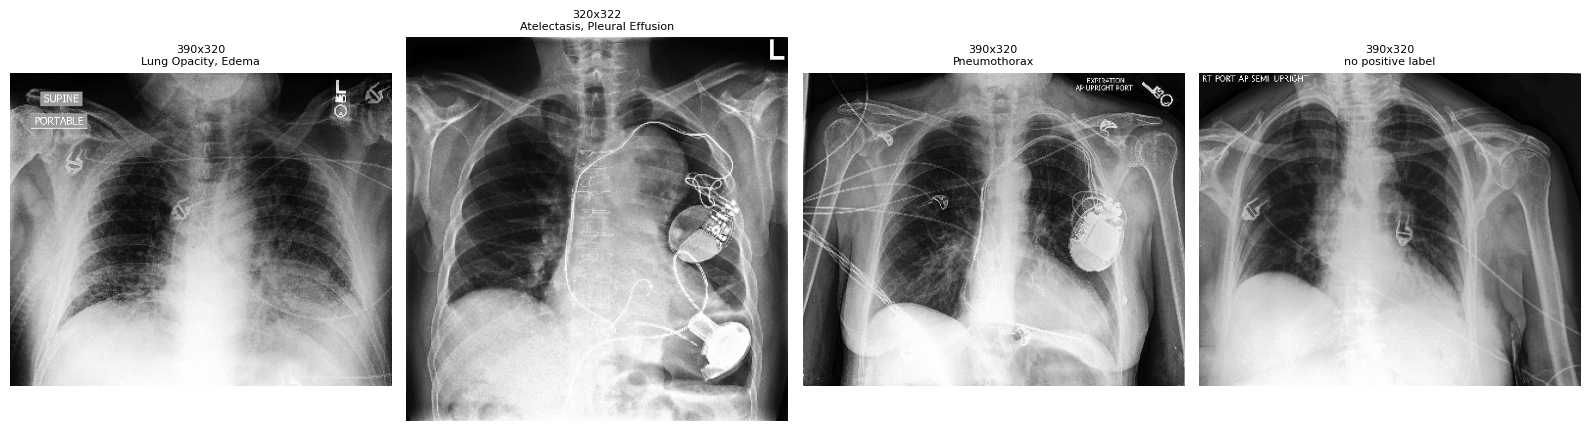

In [73]:
# 4 random frontal X-rays from the train split (titled with their positive labels)
sample_idx = np.random.choice(train_frontal.index, size=4, replace=False)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, i in zip(axes, sample_idx):
    row = train_df.loc[i]
    img = np.asarray(Image.open(resolve_path(row["Path"])).convert("L"))
    pos = [c for c in LABEL_COLS if row[c] == 1]
    ax.imshow(img, cmap="gray"); ax.axis("off")
    ax.set_title(f"{img.shape[1]}x{img.shape[0]}\n" + (", ".join(pos) if pos else "no positive label"), fontsize=8)
plt.tight_layout(); plt.show()

## Summary — EDA findings

### Dataset
- **train** 223,414 rows (191,027 frontal) · **valid** 234 (202 frontal) · **test** 668 (518 frontal).
- 14 label columns = 12 pathologies + `No Finding` (normal flag) + `Support Devices` (not a disease).
- Train labels are NLP-derived with 4 states: **1 / 0 / -1 (uncertain) / blank (not mentioned)**. valid & test are **clean radiologist binary** (no -1, no blanks).

### Findings
- **Uncertainty varies sharply per task:** among *mentioned* rows, Atelectasis 49% and Consolidation 39% are uncertain; Pleural Effusion only 9%.
- **Views:** ~85% frontal in train. `AP/PA` only applies to frontals (lateral = NaN).
- **Patient structure:** 2.91 studies/patient (max 91) → image-level splitting would leak patients. Only ~1.8% of studies have >1 frontal → per-study ≈ per-image.
- **No cross-split leakage:** train/valid/test patients are fully disjoint (0 shared).
- **Demographics:** ~59% male; age mean ~60, capped at 90 (a few `age==0` = missing). train/valid distributions match.
- **Images:** grayscale (`L`), intensity 0–255. train/valid = small version (height pinned 320; **390×320 = 70%**, top 3 sizes ≈ 89%); **test = full-resolution** (~2000–4000 px).
- **Aspect ratio** is tight (~1.2, mostly landscape).
- **Multi-label structure is real:** Pleural Effusion co-occurs with ~50% of every other task's positives; Consolidation→Atelectasis 66%.
- **Labels are consistent:** no real pathology contradicts `No Finding` (only Support Devices co-occurs, which is allowed).